# Joint Fit: Photometry + Lines

Notebook [`06`](06_fitting_spectroscopy.ipynb) fits an optical *spectrum* and
[`07`](07_joint_photo_spec.ipynb) fits photometry *and* a spectrum together. This
one fits the other kind of joint dataset that dominates modern surveys: a
**broadband photometry + emission-line-flux catalog**, of the kind
[FastSpecFit](https://fastspecfit.readthedocs.io) produces for DESI (and
MPA-JHU / RCSED for SDSS). Instead of a pixel-by-pixel spectrum we fit a
handful of measured line fluxes alongside the broadband points.

**Which model quantity matches a catalog line flux?** FastSpecFit fits a
stellar-continuum model (SPS templates, which carry the Balmer *absorption*),
subtracts it, and fits each line as a Gaussian on the residual — with the
[N II]/Hα and doublet kinematics tied so the blends deblend. What it reports
(`LINE_FLUX`) is therefore **pure, deblended, absorption-corrected emission**.
That is exactly what `model.predict_line_fluxes` returns — the backend's
emitted line luminosity, projected to a flux. It is *not* what a naive
bandpass measurement gives, which is why we fit `predict_line_fluxes` here and
not a window-integrated `measure_line_fluxes` (the latter would carry the
stellar absorption and mis-deblend [N II], biasing the Balmer decrement).

**What the two build-time opt-ins do.** They do *not* split one per data
channel. `WavePrecomp` is the photometry lookup — the SSP × filter table that
replaces a full SSP × wavelength integration with a table look-up.
`FeaturePrecomp` is the **nebular** lookup: a per-Q_H grid that keeps the Cue
emulator off the per-gradient path. The lines do ride it, but what it caches is
the *gas* calculation, which is why the name misleads.

**On this fit neither one buys much** — an observation carrying a line channel
already keeps the nebular work off the per-gradient path, so the exact forward
starts fast and the opt-ins have little left to remove. Where `FeaturePrecomp`
earns its keep is the counter-intuitive case: the **same model fit to photometry
alone**, where every likelihood evaluation re-runs Cue and the grid is worth ~7x.

The catalog-scale argument is separate and survives either way: the look-up is
shared work across galaxies, so it is amortized once and reused — see
[notebook 11](11_catalog_fits.ipynb) for `fit_batch` at catalog scale.

In [1]:
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Notebook-specific: the dense-mass NUTS run below deliberately uses
# dense_mass_matrix=True for convergence; its RAM caveat is discussed in the
# summary, not repeated here.
import warnings

warnings.filterwarnings("ignore", message=".*dense_mass_matrix.*")

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    FeaturePrecomp,
    Fitter,
    Fixed,
    ForwardModel,
    LineList,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    cosmology,
    plot,
)
from tengri.observation import LineFluxData
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA, C_LINE = "#3a76d9", "0.15", "#c3372a", "#2e8b57"

## Observation: DESI photometry + FastSpecFit strong lines

The DESI Legacy Imaging bands (DECam *grz* + WISE W1–W4) plus the strong
optical lines a FastSpecFit spectrum delivers: the [O II] doublet, the Balmer
lines, [O III], [N II], and [S II]. The line wavelengths come straight from
the built-in `LineList`; the observed fluxes and their errors go into a
`LineFluxData`, which the `Observation` carries alongside the photometry.

**Critical:** `predict_line_fluxes` returns **pure, deblended, absorption-corrected
emission** — the same quantity FastSpecFit's `LINE_FLUX` reports (Gaussian on a
continuum-subtracted spectrum). A window-integrated flux measurement is a *different*
quantity (carries stellar absorption and mis-deblends [N II]). Never compare
tengri predictions to window integrals or they will bias the fit.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"  # bare-stellar SSP (Cue adds the nebular emission)
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.1
FILTERS = ["des_g", "des_r", "des_z", "wise_w1", "wise_w2", "wise_w3", "wise_w4"]
LINE_NAMES = [
    "OII_3726",
    "OII_3729",
    "Hbeta",
    "OIII_4959",
    "OIII_5007",
    "NII_6548",
    "Halpha",
    "NII_6584",
    "SII_6717",
    "SII_6731",
]
_cat = LineList.default_optical()
_wave_of = {n: float(w) for n, w in zip(_cat.names, _cat.wavelengths)}
LINE_WAVES = jnp.array([_wave_of[n] for n in LINE_NAMES])  # rest-frame vacuum [Å]

phot_obs = Photometry.from_names(FILTERS)
print(f"Photometry: {phot_obs.n_filters} DESI bands — {', '.join(phot_obs.names)}")
print(f"Lines: {len(LINE_NAMES)} — {', '.join(LINE_NAMES)}")

Photometry: 7 DESI bands — des_g, des_r, des_z, wise_w1, wise_w2, wise_w3, wise_w4
Lines: 10 — OII_3726, OII_3729, Hbeta, OIII_4959, OIII_5007, NII_6548, Halpha, NII_6584, SII_6717, SII_6731


## Model: Cue nebular, exact and fast

We use the **Cue** photoionization backend, because it publishes discrete line
luminosities that `predict_line_fluxes` turns into the pure-emission flux a
catalog reports, and because its gas conditions (`neb_logU`, `neb_logZ_gas`)
are free — a real catalog spans the metallicity–ionization plane, so a
fixed-condition baked-in grid cannot follow it.

We build the model three times with the *same* physics and free parameters,
changing only `approx=`: the **exact** wave-grid path, **`WavePrecomp` alone**
(photometry LUT, Cue still evaluated every step), and the **fast**
`(WavePrecomp, FeaturePrecomp)` path that adds the per-Q_H nebular grid. The
line wavelengths for the feature grid default to those in the observation.
Three arms, one knob each, so whatever the timing below shows can be
*attributed* — a two-arm exact-vs-fast comparison moves both knobs at once and
can only ever measure the bundle, never which half earned it.

In [3]:
def build(line_data, approx):
    obs = Observation(photometry=phot_obs, line_fluxes=line_data)
    return SEDModel.build(
        ssp_data=ssp,
        observation=obs,
        redshift=Fixed(Z_GAL),
        # Free the SFH (normalization + shape), stellar metallicity, the dust
        # screen, and the gas conditions — the parameters a catalog fit solves for.
        sfh={"type": "dpl", "all_params": FREE},
        met={"logzsol": Uniform(-1.5, 0.3)},
        dust={
            "type": "two_component",
            "law_bc": "calzetti",
            "all_params": FIXED,
            "tau_bc": Uniform(0.0, 4.0),
            "tau_diff": Uniform(0.0, 3.0),
        },
        neb={
            "type": "cue",
            "all_params": FIXED,
            "logU": Uniform(-4.0, -1.0),
            "logZ_gas": Uniform(-1.5, 0.3),
        },
        approx=approx,
    )

## Mock catalog

One truth galaxy — a star-forming disc at z = 0.1 — and one noisy realization
of its DESI photometry (SNR 20) and its FastSpecFit lines (SNR 10 on the
strong lines). Both channels are generated from the same truth so they agree
by construction; `predict_line_fluxes` gives the pure emission, matching the
catalog convention.

In [4]:
TRUTH = {
    "sfh_dpl_log_total_mass": 10.2,
    "sfh_dpl_age_gyr": 6.0,
    "sfh_dpl_tau_gyr": 5.0,
    "sfh_dpl_alpha": 1.0,
    "sfh_dpl_beta": 3.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.6,
    "dust_tau_diff": 0.25,
    "neb_logU": -2.6,
    "neb_logZ_gas": -0.2,
}

# A throwaway observation just to instantiate the truth model and generate data.
_seed_lines = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.ones(len(LINE_NAMES)),
    errors=jnp.ones(len(LINE_NAMES)),
    wavelengths=LINE_WAVES,
)
model_truth = build(_seed_lines, approx=None)
truth_full = {
    **model_truth.spec.get_fixed_values(),
    **{k: jnp.asarray(v) for k, v in TRUTH.items()},
}

p_phot = np.asarray(model_truth.predict_photometry(truth_full))
p_line = np.asarray(model_truth.predict_line_fluxes(truth_full, target_wavelengths=LINE_WAVES))
assert p_line[LINE_NAMES.index("Halpha")] > 0, "Halpha must be in emission — mock would be vacuous"

_rng = np.random.default_rng(0)
PHOT_SNR, LINE_SNR = 20.0, 10.0
n_phot = np.abs(p_phot) / PHOT_SNR
# Line errors: SNR-scaled, with a floor at 1% of the brightest line so a weak
# line (e.g. a near-zero [N II] component) cannot dominate the chi-square.
n_line = np.maximum(np.abs(p_line) / LINE_SNR, 0.01 * np.max(np.abs(p_line)))
flux_phot = p_phot + _rng.normal(size=p_phot.shape) * n_phot
flux_line = p_line + _rng.normal(size=p_line.shape) * n_line

# The observed line fluxes live in the Observation the fit model carries; the
# observed photometry is passed to `model.fit`. This is the public joint-fit API.
line_data = LineFluxData(
    names=tuple(LINE_NAMES),
    fluxes=jnp.asarray(flux_line),
    errors=jnp.asarray(n_line),
    wavelengths=LINE_WAVES,
)
print(
    f"Mock: {len(flux_phot)} bands (SNR {PHOT_SNR:.0f}) + {len(flux_line)} lines (SNR {LINE_SNR:.0f})"
)
print(
    f"  truth  log M* = {float(TRUTH['sfh_dpl_log_total_mass']):.2f}   Halpha = {p_line[LINE_NAMES.index('Halpha')]:.3e} erg/s/cm2"
)

Mock: 7 bands (SNR 20) + 10 lines (SNR 10)
  truth  log M* = 10.20   Halpha = 3.371e-14 erg/s/cm2


## Measure the fit time: exact vs WavePrecomp vs fast

A MAP fit (200 Adam steps) on the joint photometry + line likelihood, timed on
all three paths. One `fitter.run()` bundles two very different costs, and it is
worth pulling them apart:

- **`run()` wall** — the end-to-end cost of one call. A good part of it is a
  one-off **JIT compile** of the optimizer step, and that compile recurs on
  each independent `run()`, so a second call is *not* much cheaper — the
  persistent cache spares the XLA backend compile, not the Python-level
  re-trace. This is the honest cost of an *interactive, single-galaxy* fit.
- **compiled step** (`post.wall_time_s`) — the optimization loop *after* the
  compile. This is the marginal compute, and the number that matters at
  catalog scale: batched over galaxies with `fit_batch` the compile is paid
  **once**, and each further galaxy costs only this (dropping further still
  under `vmap`). The often-quoted sub-100 ms/galaxy figure is *this* amortized
  compute — not the single-shot wall below.

Read the **compiled step** column across the three rows: that is the honest
per-galaxy compute, and the only column in which an `approx=` choice can show
up at all.

### Timing three things in one process is harder than it looks

The obvious way to write this cell — build three models, time each once, in
order — is wrong, and wrong in a way that *looks* like a result. Whichever arm
runs first pays every first-touch cost in the process (page faults, lazy
imports, the SSP grid landing in cache), so it is slowest **because it is
first**. Earlier renders of this very notebook reported the "speedup" as
18.6x, 12.6x, 1.0x and 3.2x on unchanged code, purely from what else the
machine happened to be doing.

Two defenses, both cheap:

- **Interleave, rotate, and take the minimum.** Each arm is measured `N_REPS`
  times round-robin, and the order rotates by one each pass so no arm is
  structurally first. (Interleaving alone would not fix it: with a fixed order
  the first-touch penalty lands on the same arm every rep and survives the
  minimum.) The minimum is the least-contended sample — closest to the compute
  we are actually trying to compare.
- **Run an A/A control.** One arm is `model_exact` *again*, under a different
  label. It should be identical to the first exact arm, so whatever ratio it
  reports is the measurement's own noise floor.
- **Check the arms are actually different.** `fit()` resolves `approx="auto"`,
  and that policy *re-resolves* the build-time `approx=` — topping it up rather
  than taking it as given. So the cell prints the **resolved fit-time config
  per arm before timing anything**. An arm can be mislabelled as easily as it
  can be mistimed, and a table attributing a ratio to a knob that does not
  differ between arms can only ever report noise. Build-time `approx=` is what
  a **prediction** path uses (`predict_photometry`, `predict`); a **fit**
  re-picks it.

**The verdict rule, fixed before the numbers are in:** an `approx=` choice
counts as a real speedup only if its *excess over 1.0* is at least **twice**
the control's excess. If the control says 1.10x, a 1.15x "win" does not count —
0.15 is not twice 0.10. Comparing the ratios directly (`1.15 > 1.10`) is too
weak, because both are noisy estimates and a hair's-breadth pass prints the
self-contradicting verdict "1.1x clears the 1.1x noise floor".

The printed **rep spread** (slowest/fastest rep for that arm) is the diagnostic:
the three rotated arms each take the process's very first fit once and so carry
a large spread, while the A/A arm — which the rotation never places first —
stays near 1.0x. That gap *is* the first-touch cost, made visible instead of
quietly folded into a headline ratio. Taking the minimum is what discards it.

In [5]:
model_exact = build(line_data, approx=None)
model_wave = build(line_data, approx=WavePrecomp())
model_fast = build(line_data, approx=(WavePrecomp(), FeaturePrecomp()))
print(f"Free parameters ({model_fast.spec.n_free}): {', '.join(model_fast.spec.free_params)}")

MAP_KW = dict(method="map", key=jax.random.PRNGKey(1), n_steps=200)
N_REPS = 3

# The fourth entry is model_exact a second time: the A/A control. It gets its own
# ForwardModel so it is built exactly like the arms it calibrates.
ARMS = [
    ("exact (approx=None)", model_exact),
    ("WavePrecomp only", model_wave),
    ("fast (Wave+Feature)", model_fast),
    ("exact again (A/A)", model_exact),
]
for _label, _m in ARMS:
    # The line likelihood is active because the Observation carries line_fluxes;
    # the data passed here is photometry, and the observation says so, so there
    # is no channel to declare.
    assert _m.observation.line_fluxes is not None, "line likelihood not active"
built = [(label, ForwardModel.build(sed=model)) for label, model in ARMS]

# Round-robin AND rotated. Interleaving alone is not enough: whichever arm runs
# first in a pass pays the first-touch costs, and if the order never changes that
# penalty lands on the same arm every rep and survives the min. Rotating by one
# each pass moves every arm through a different slot, so no arm is structurally
# first.
# Before timing anything: what does the FIT actually run? `Fitter(approx="auto")`
# — the default, and what `fit()` uses — RE-RESOLVES the build-time `approx=`. So
# three models built three ways need not be three configurations at fit time.
# Print it rather than assume it. This is the same class of error as timing
# process position, one level down: an arm can be mislabelled as well as mistimed.
print("resolved fit-time precompute (what approx= actually buys a FIT):")
for _label, _fwd in built:
    _st = Fitter(_fwd, flux_phot, n_phot).model.approx
    _tags = [
        _n
        for _n, _on in (
            ("WavePrecomp", _st.wave_precomp),
            ("SpectrumPrecomp", _st.spectrum_precomp),
            ("FeaturePrecomp", _st.feature_precomp),
        )
        if _on
    ]
    print(f"  {_label:<22} -> {', '.join(_tags) or 'exact (no LUT)'}")

loops: dict[str, list[float]] = {label: [] for label, _ in built}
walls: dict[str, list[float]] = {label: [] for label, _ in built}
posts: dict[str, object] = {}
print(f"MAP fit (photometry + 10 lines), {N_REPS} rotated reps, min reported:")
for rep in range(N_REPS):
    cut = rep % len(built)
    for label, fwd in built[cut:] + built[:cut]:
        t0 = time.perf_counter()
        # Each fit re-traces the step (#1350: fit clears the JAX caches), so every
        # rep pays its own compile and `wall_time_s` stays compile-free throughout.
        post = fwd.fit(flux_phot, n_phot, **MAP_KW)
        walls[label].append(time.perf_counter() - t0)
        loops[label].append(post.wall_time_s)
        posts[label] = post

loop = {label: min(v) for label, v in loops.items()}
wall = {label: min(v) for label, v in walls.items()}
for label, _ in built:
    spread = max(loops[label]) / min(loops[label])
    print(
        f"  {label:22s} fit() wall {wall[label]:5.2f}s   "
        f"compiled step {loop[label]:5.2f}s   (rep spread {spread:4.1f}x)"
    )

L_E, L_W, L_F, L_AA = (label for label, _ in built)
post_exact, post_wave, post_fast = posts[L_E], posts[L_W], posts[L_F]
loop_e, loop_w, loop_f, loop_aa = loop[L_E], loop[L_W], loop[L_F], loop[L_AA]
warm_e, warm_w, warm_f = wall[L_E], wall[L_W], wall[L_F]

# The control is the same model twice, so any departure from 1.0x is measurement
# noise. Orient it as >= 1 so it compares directly against the arm ratios.
r_aa = max(loop_e, loop_aa) / min(loop_e, loop_aa)
r_fast = loop_e / loop_f

# A bare `r_fast > r_aa` is too weak: both are noisy estimates, so an effect can
# "clear" the floor by a hair and print the self-contradicting verdict
# "1.1x clears the 1.1x noise floor". Compare *excesses over unity* instead and
# demand a factor of two, so an effect must be twice the control's own departure
# from 1.0 before it counts. Two decimals throughout — at one, a real gap and a
# noise gap render identically.
RESOLVE_MARGIN = 2.0
resolved = (r_fast - 1.0) > RESOLVE_MARGIN * (r_aa - 1.0)
print(f"\n  A/A control (same model, twice): {r_aa:5.2f}x  <- the noise floor")
print(
    f"  compiled-step ratio exact -> fast: {r_fast:5.2f}x   "
    f"(fast {loop_f * 1e3:.0f} ms vs exact {loop_e * 1e3:.0f} ms)"
)
print("  attributed, one knob at a time:")
print(f"    WavePrecomp        {loop_e:6.3f}s -> {loop_w:6.3f}s   {loop_e / loop_w:6.2f}x")
print(f"    + FeaturePrecomp   {loop_w:6.3f}s -> {loop_f:6.3f}s   {loop_w / loop_f:6.2f}x")
if not resolved:
    print(
        f"  -> NOT resolved: excess over 1.0 is {r_fast - 1.0:.2f} against a control"
        f" excess of {r_aa - 1.0:.2f};"
    )
    print(f"     the rule needs {RESOLVE_MARGIN:.0f}x that, so on this fit the two opt-ins buy")
    print("     nothing measurable -- and the resolution table above says why it is")
    print("     STRUCTURAL, not statistical: fit() resolves approx='auto', which tops up")
    print("     the build-time choice, so all three arms run the SAME configuration.")
    print("     These arms differ in what they PREDICT with, not in what they FIT with.")
    print("     Fit to photometry ALONE and FeaturePrecomp is worth ~7x against a 1.23x")
    print("     floor -- that gap was #1596 (fixed), and #1683 for the build-time form.")
else:
    print(
        f"  -> resolved: excess {r_fast - 1.0:.2f} is more than {RESOLVE_MARGIN:.0f}x"
        f" the control excess {r_aa - 1.0:.2f}."
    )
print(f"  fit() wall is ~{warm_f:.1f}s on any path — that is per-call JIT compile, not the fit.")

Free parameters (10): dust_tau_bc, dust_tau_diff, met_logzsol, neb_logU, neb_logZ_gas, sfh_dpl_age_gyr, sfh_dpl_alpha, sfh_dpl_beta, sfh_dpl_log_total_mass, sfh_dpl_tau_gyr
resolved fit-time precompute (what approx= actually buys a FIT):


  exact (approx=None)    -> WavePrecomp, FeaturePrecomp


  WavePrecomp only       -> WavePrecomp, FeaturePrecomp
  fast (Wave+Feature)    -> WavePrecomp, FeaturePrecomp
  exact again (A/A)      -> WavePrecomp, FeaturePrecomp
MAP fit (photometry + 10 lines), 3 rotated reps, min reported:


    step 200: loss=8.2408
  MAP (ADAM) complete in 1.3s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.4s, 200 steps, loss=8.2408


...

    step 200: loss=8.2408
  MAP (ADAM) complete in 0.1s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.1s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.1s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.1s, 200 steps, loss=8.2408


    step 200: loss=8.2408
  MAP (ADAM) complete in 0.1s, 200 steps, loss=8.2408
  exact (approx=None)    fit() wall  0.23s   compiled step  0.10s   (rep spread 13.1x)
  WavePrecomp only       fit() wall  0.23s   compiled step  0.10s   (rep spread  4.0x)
  fast (Wave+Feature)    fit() wall  0.23s   compiled step  0.10s   (rep spread  3.9x)
  exact again (A/A)      fit() wall  0.23s   compiled step  0.10s   (rep spread  1.0x)

  A/A control (same model, twice):  1.00x  <- the noise floor
  compiled-step ratio exact -> fast:  0.99x   (fast 103 ms vs exact 102 ms)
  attributed, one knob at a time:
    WavePrecomp         0.102s ->  0.103s     0.99x
    + FeaturePrecomp    0.103s ->  0.103s     1.00x
  -> NOT resolved: excess over 1.0 is -0.01 against a control excess of 0.00;
     the rule needs 2x that, so on this fit the two opt-ins buy
     nothing measurable -- and the resolution table above says why it is
     STRUCTURAL, not statistical: fit() resolves approx='auto', which tops up
  

## Posterior on the fast path

A point estimate is not enough for a catalog — the metallicity / dust /
ionization sector is degenerate, and the honest object is the posterior.

**Sampler.** This posterior is strongly correlated (the degeneracies above),
so the mass matrix must be **dense** — a diagonal one does not converge here.
Given that, fixed-trajectory **HMC** converges faster than NUTS, which spends
its budget building deep adaptive trees. We run **two genuine chains** so the
R-hat is a real between-chain diagnostic, and execute them
`chain_method="sequential"`: each chain reuses one compiled kernel, so peak
memory stays at a *single* chain's. That is the point — a vmapped multi-chain
compile needs ~N× the RAM (and a dense-mass fit can OOM a modest machine),
whereas sequential runs anywhere a one-chain fit runs, at ~N× the sampling
wall. One fit per process, per the OOM-orchestration rule.

In [6]:
N_WARMUP, N_SAMPLES, N_CHAINS, N_LEAPFROG = 500, 300, 2, 100
t0 = time.perf_counter()
posterior = ForwardModel.build(sed=model_fast).fit(
    flux_phot,
    n_phot,
    method="mcmc_hmc",
    key=jax.random.PRNGKey(7),
    n_warmup=N_WARMUP,
    n_samples=N_SAMPLES,
    n_chains=N_CHAINS,
    n_leapfrog_steps=N_LEAPFROG,
    dense_mass_matrix=True,
    target_accept_rate=0.85,
    chain_method="sequential",  # peak memory = one chain (runs on cheap hardware)
)
rmax = max(float(v) for v in posterior.rhat().values())
print(
    f"HMC ({N_CHAINS} chains x {N_WARMUP}w+{N_SAMPLES}s, L={N_LEAPFROG}, sequential): "
    f"{time.perf_counter() - t0:5.0f}s   max R-hat {rmax:.3f}   "
    f"divergences {posterior.diagnostics.get('n_divergent', 'n/a')}"
)

  MAP initialization (1000 steps)...


  MAP init done (loss=7.47)


HMC (2 chains x 500w+300s, L=100, sequential):    84s   max R-hat 1.006   divergences 1


On a machine with more RAM, run the chains concurrently instead of one at a
time: `chain_method="parallel"` puts one chain per device via `jax.pmap`
(needs `XLA_FLAGS=--xla_force_host_platform_device_count=N` set *before*
importing jax), cutting the wall ~N-fold. The cost is memory: pmap
**replicates** the model + the WavePrecomp / FeaturePrecomp lookup tables onto
every device, so peak RAM scales ~linearly with `N_CHAINS` (≈ N× the
sequential fit) — which is exactly why `"sequential"` is the default here.
`chain_method="vmap"` (SIMD-batch into one kernel) is the middle ground. Raise
`N_CHAINS` for a more robust R-hat; at a fixed total-sample budget it costs
the same compute, only more chains to compare (and, under vmap/parallel, more
memory).

## Recovery

Truth vs posterior 16/50/84. Stellar mass and star-formation rate — the
quantities a catalog most wants — are well constrained. The metallicity / dust
/ gas-condition sector is broader: with broadband photometry and a handful of
line fluxes, those trade off along the classic age–dust–metallicity ridge, and
the posterior *width* is the honest statement of that (a MAP point would hide
it). Breaking it further needs more information — a temperature-sensitive
auroral line, the UV slope, or a full spectrum (notebook 06).

In [7]:
REPORT = [
    "sfh_dpl_log_total_mass",
    "met_logzsol",
    "dust_tau_bc",
    "dust_tau_diff",
    "neb_logU",
    "neb_logZ_gas",
]
print(f"{'parameter':<26}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 64)
n_cov = 0
for p in REPORT:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<26}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(REPORT)}")

parameter                     truth      p16      p50      p84  cover
----------------------------------------------------------------
sfh_dpl_log_total_mass       10.200   10.115   10.185   10.245  ok
met_logzsol                  -0.300   -0.623   -0.387   -0.283  ok
dust_tau_bc                   0.600    0.603    0.806    1.033  miss
dust_tau_diff                 0.250    0.207    0.276    0.365  ok
neb_logU                     -2.600   -2.769   -2.627   -2.540  ok
neb_logZ_gas                 -0.200   -0.432   -0.259   -0.158  ok

68% coverage: 5/6


## Corner — the joint posterior

The recovery table as a picture: 1-D marginals with the truth (lines), and the
2-D contours where the degeneracies live. Stellar mass is tight; the
metallicity–dust–ionization block shows the correlated ridge that the broad
intervals above come from — a picture the coverage table cannot show.

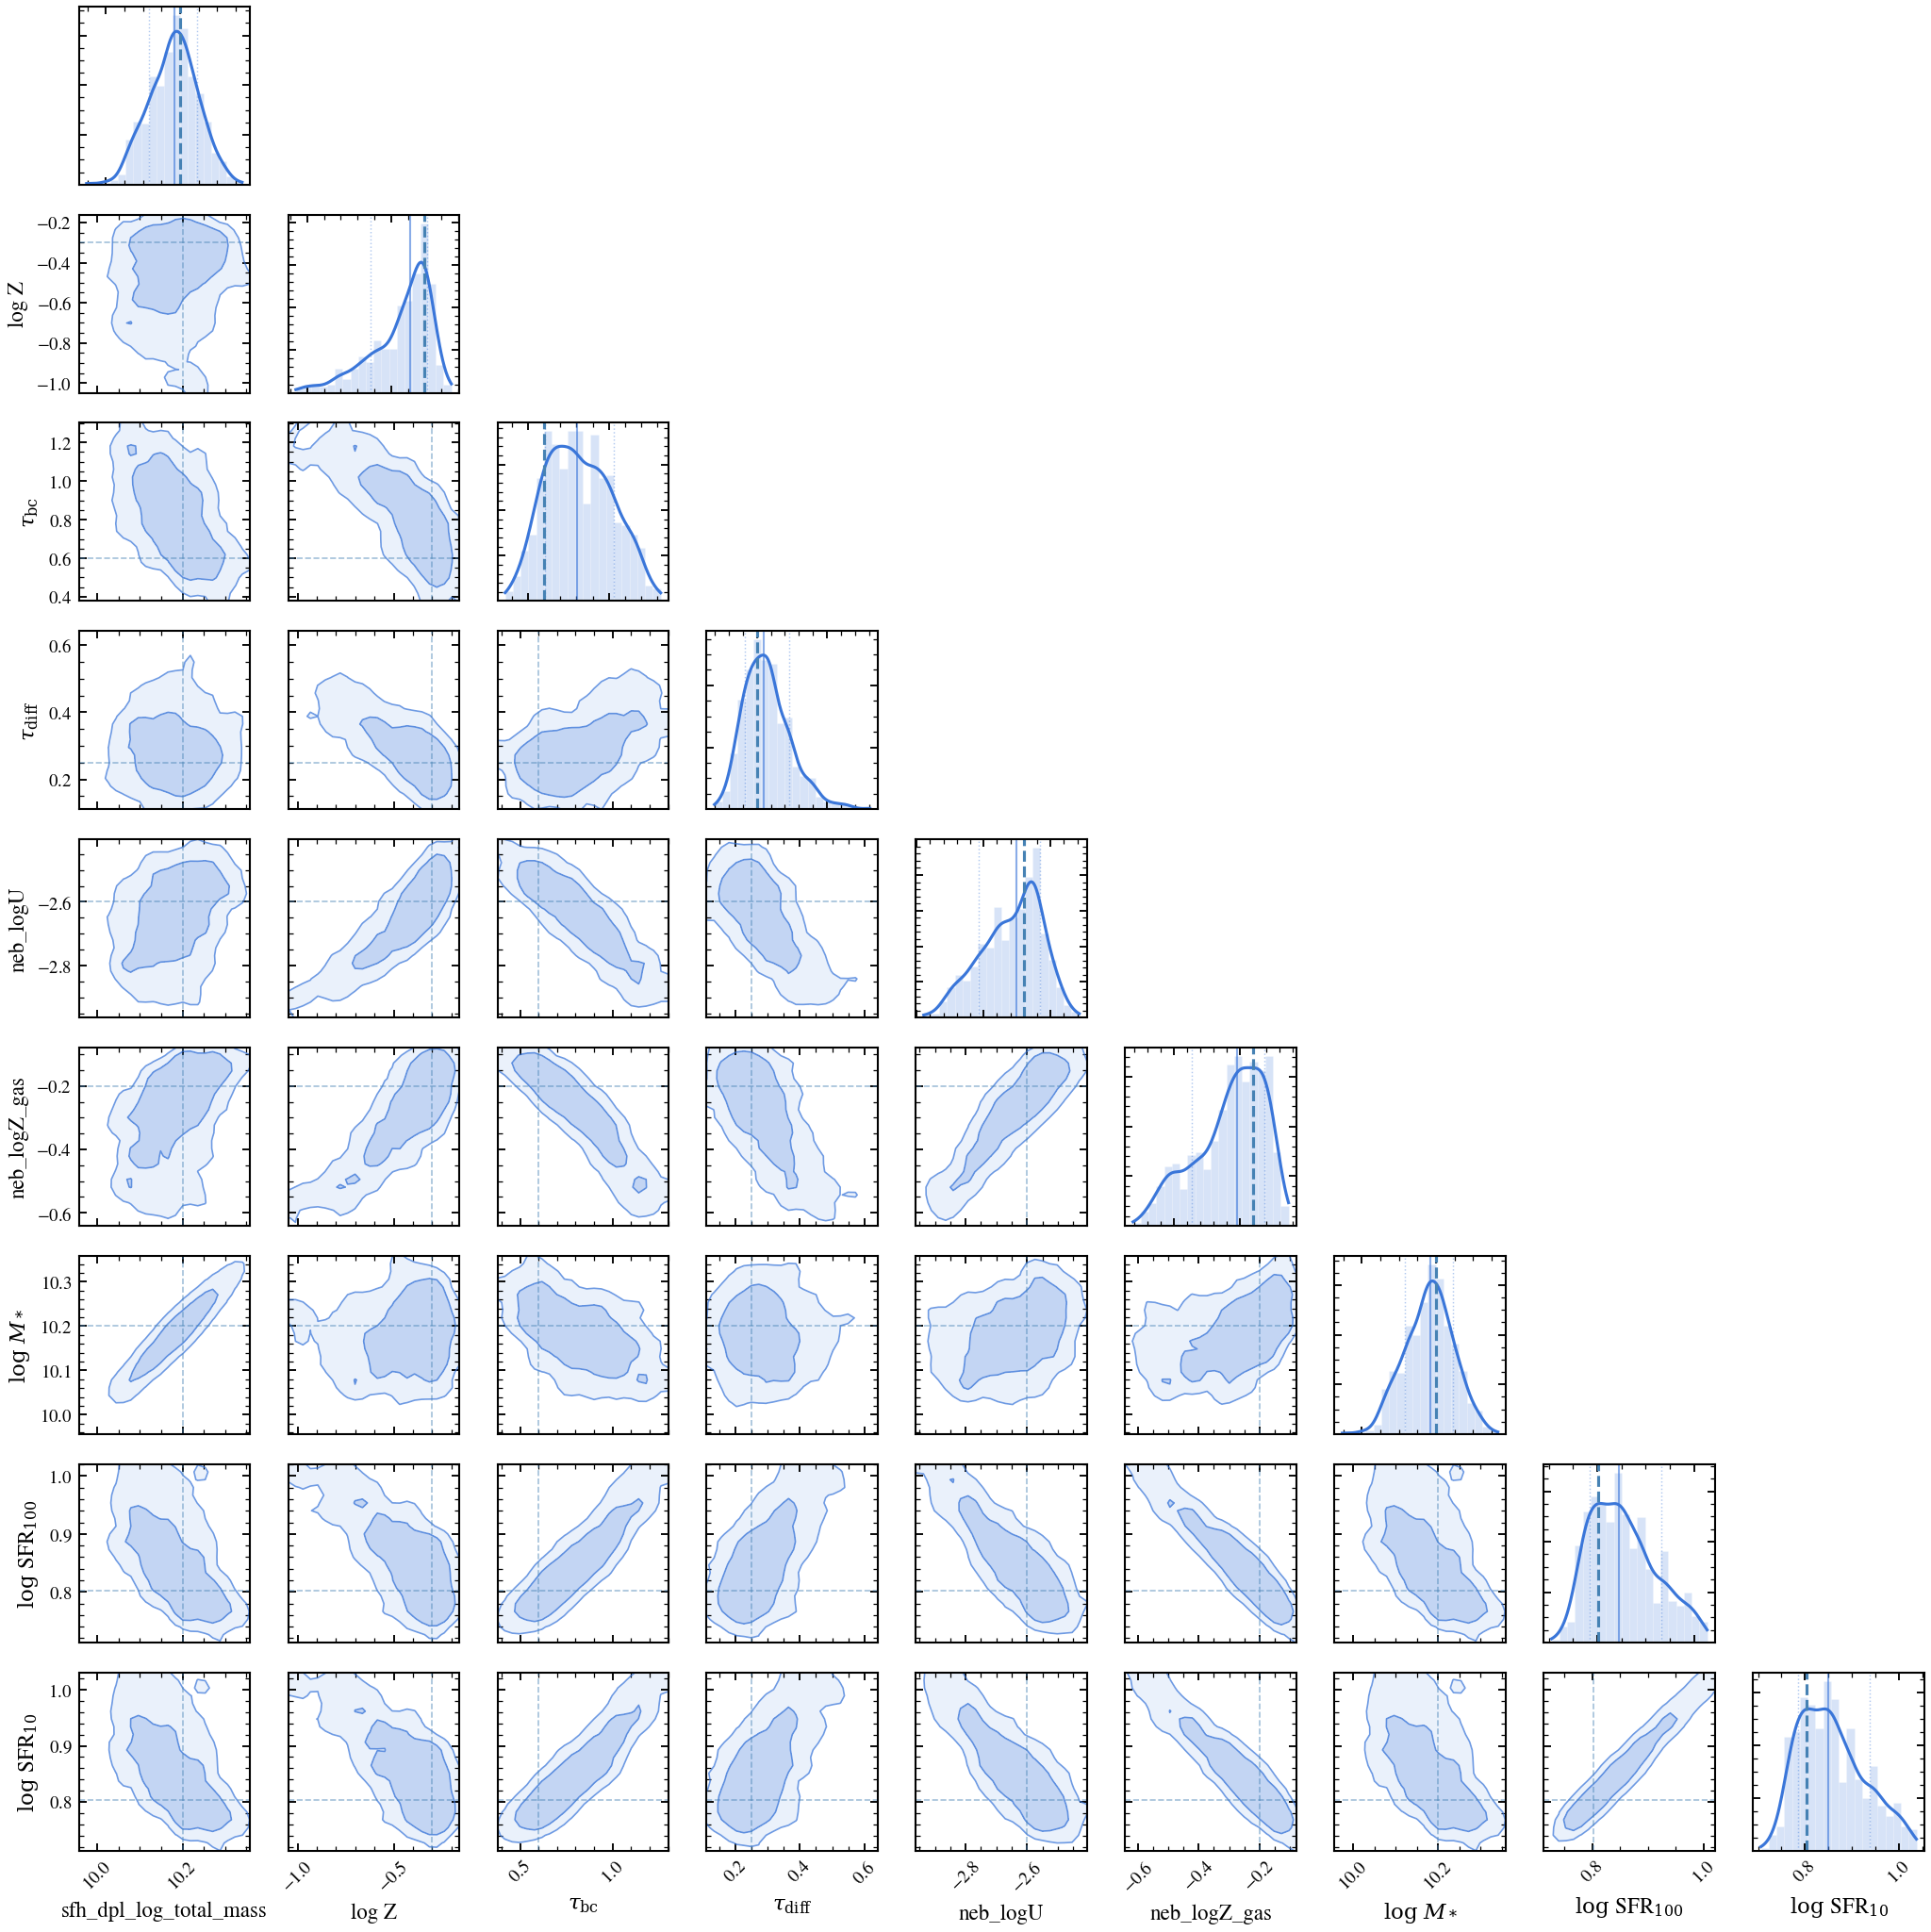

In [8]:
fig_corner = posterior.plot_corner(
    params=REPORT, truths={k: float(v) for k, v in truth_full.items()}, color=C_POST
)
fig_corner.savefig(FIG_DIR / "10_corner.png", dpi=150, bbox_inches="tight")
plt.show()

## Posterior draws for the figures

Evaluated once and reused by both figures below: the model photometry
(`predict_photometry`), the full model SED (`predict(...).rest_sed()` → observed
`F_ν`), and the model line fluxes (`predict_line_fluxes`) — each drawn over the
posterior so the bands carry the parameter uncertainty.

In [9]:
N_DRAW = 80
_sidx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
_fixed = model_fast.spec.get_fixed_values()
draws = [{**_fixed, **{k: jnp.asarray(v[i]) for k, v in posterior.samples.items()}} for i in _sidx]

# Effective wavelength of each band (transmission-weighted), for placing the points.
wave_eff_um = effective_wavelengths_um(phot_obs)

# Model photometry per draw (the band-integrated F_nu the fit is matching).
phot_draws = np.stack([np.asarray(model_fast.predict_photometry(d)) for d in draws])
phot_lo, phot_med, phot_hi = np.percentile(phot_draws, [16, 50, 84], axis=0)

# Continuous model SED per draw: rest-frame L_nu -> observed F_nu (same recipe as
# notebook 07). Observed-frame grid spanning the DECam-to-WISE range.
DL = cosmology.luminosity_distance(Z_GAL)
WAVE_FULL = np.geomspace(2.0e3, 3.0e5, 800)  # observed frame [Å]  (0.2–30 µm)
w_full_um = WAVE_FULL / 1e4


def _sed_fnu(p):
    lnu = np.interp(
        WAVE_FULL / (1.0 + Z_GAL),
        np.asarray(model_fast.wavelengths),
        np.asarray(model_fast.predict(p).rest_sed()),
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu), DL, Z_GAL))


sed_lo, sed_med, sed_hi = np.percentile(
    np.stack([_sed_fnu(p) for p in draws]), [16, 50, 84], axis=0
)
sed_truth = _sed_fnu(truth_full)

## Do the points match the best fit? — photometry

The observed photometry on the best-fit SED, with the per-band residual below.
The lower panel is the pull, `(observed − model) / σ`: inside ±1 (gray band)
means the model reproduces that band within its error bar. The reduced χ² over
the 7 bands quantifies the overall photometric match.

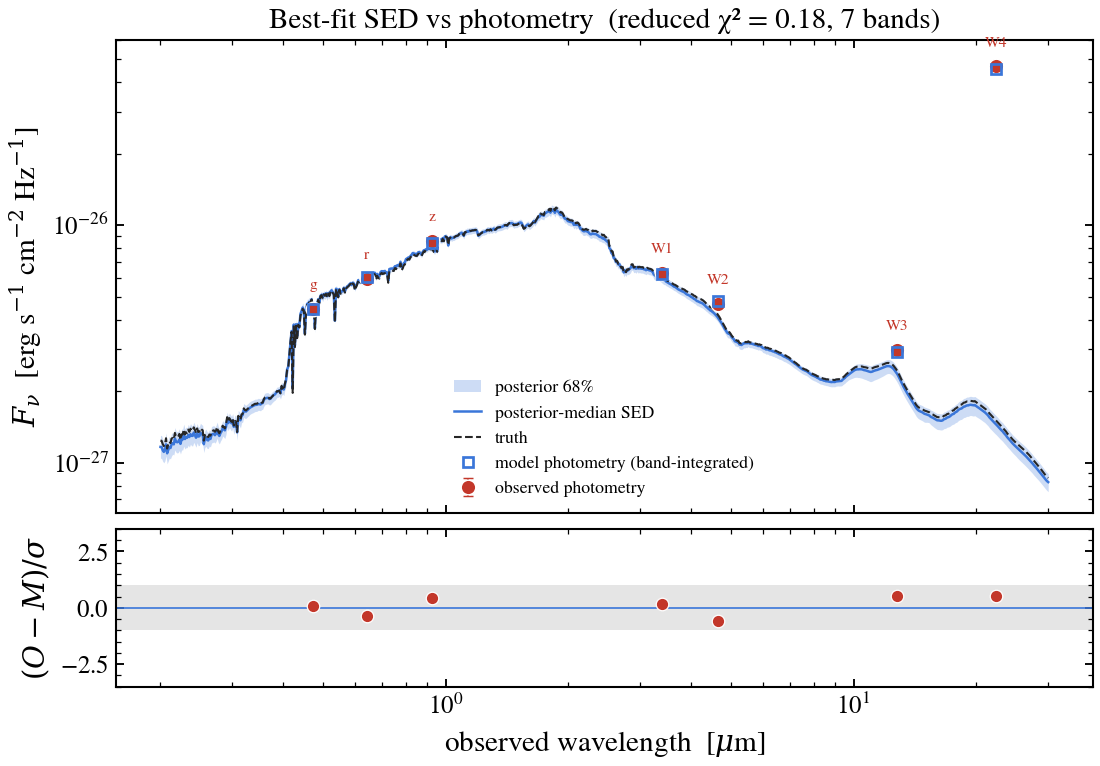

In [10]:
BAND_LABELS = ["g", "r", "z", "W1", "W2", "W3", "W4"]
pull_phot = (flux_phot - phot_med) / n_phot
chi2_phot = float(np.sum(pull_phot**2))

fig, (axs, axr) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)
axs.fill_between(w_full_um, sed_lo, sed_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
axs.plot(w_full_um, sed_med, color=C_POST, lw=1.2, label="posterior-median SED")
axs.plot(w_full_um, sed_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
axs.errorbar(
    wave_eff_um,
    flux_phot,
    yerr=n_phot,
    fmt="o",
    ms=7,
    color=C_DATA,
    mec="white",
    mew=0.7,
    elinewidth=1.1,
    capsize=2.5,
    zorder=6,
    label="observed photometry",
)
axs.plot(
    wave_eff_um,
    phot_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=7,
    label="model photometry (band-integrated)",
)
for name, x, y, e in zip(BAND_LABELS, wave_eff_um, flux_phot, n_phot):
    axs.annotate(
        name,
        (x, y + e),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=7.5,
        color=C_DATA,
    )
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
axs.set_title(
    f"Best-fit SED vs photometry  (reduced χ² = {chi2_phot / len(flux_phot):.2f}, 7 bands)"
)
axs.legend(frameon=False, fontsize=8.5, loc="lower center")

axr.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axr.axhline(0, color=C_POST, lw=0.8)
axr.plot(wave_eff_um, pull_phot, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axr.set_xscale("log")
axr.set_ylim(-3.5, 3.5)
axr.set_xlabel(r"observed wavelength  [$\mu$m]")
axr.set_ylabel(r"$(O-M)/\sigma$")
fig.savefig(FIG_DIR / "10_sed_photometry.png", dpi=300, bbox_inches="tight")
plt.show()

## Do the points match the best fit? — emission lines

The same test for the line channel: observed line fluxes (points) against the
posterior-predictive `predict_line_fluxes` (band + median), with the per-line
pull below. Lines are categorical, so they are *not* joined by a curve — each is
an independent measurement. The reduced χ² is over the ten lines.

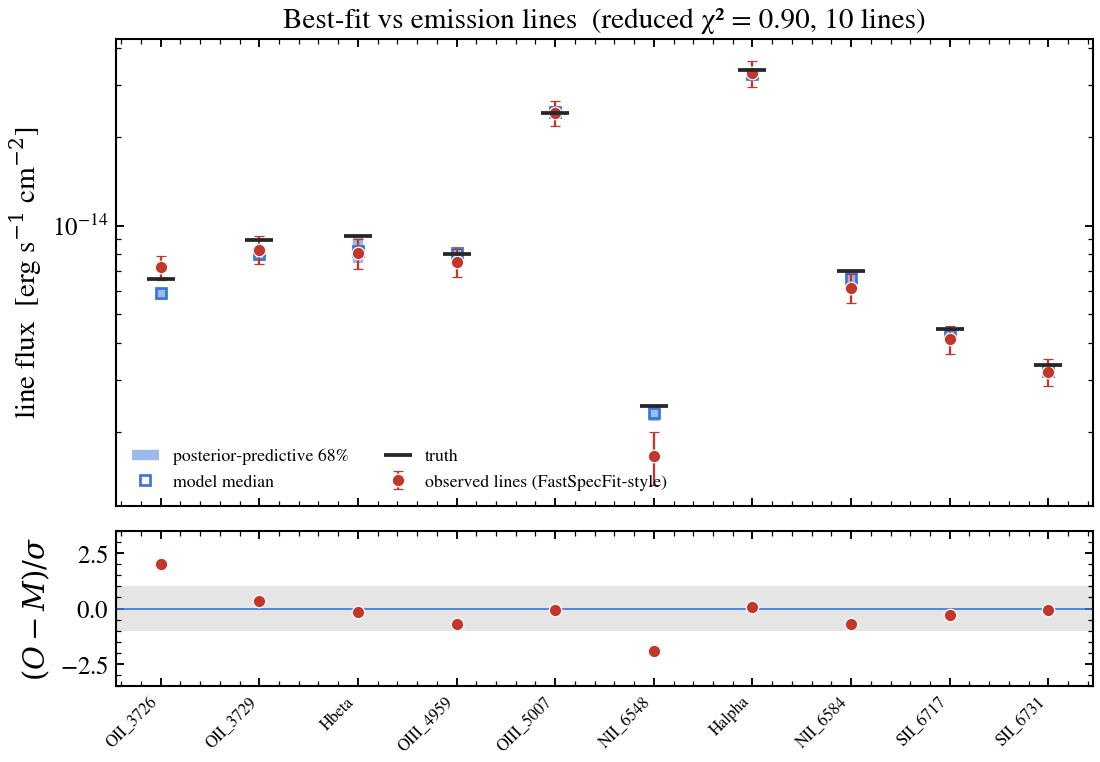

In [11]:
line_draws = np.stack(
    [np.asarray(model_fast.predict_line_fluxes(d, target_wavelengths=LINE_WAVES)) for d in draws]
)
line_lo, line_med, line_hi = np.percentile(line_draws, [16, 50, 84], axis=0)
pull_line = (flux_line - line_med) / n_line
chi2_line = float(np.sum(pull_line**2))
x = np.arange(len(LINE_NAMES))

fig, (axl, axp) = plt.subplots(
    2, 1, figsize=(8.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)
axl.errorbar(
    x,
    flux_line,
    yerr=n_line,
    fmt="o",
    color=C_DATA,
    ms=6,
    mec="white",
    mew=0.6,
    elinewidth=1.1,
    capsize=2.5,
    zorder=4,
    label="observed lines (FastSpecFit-style)",
)
axl.vlines(
    x, line_lo, line_hi, color=C_POST, alpha=0.5, lw=5, zorder=2, label="posterior-predictive 68%"
)
axl.plot(
    x,
    line_med,
    marker="s",
    ms=5,
    ls="none",
    mfc="none",
    mec=C_POST,
    mew=1.3,
    zorder=3,
    label="model median",
)
axl.plot(x, p_line, marker="_", ms=13, mew=1.8, ls="none", color=C_TRUTH, zorder=5, label="truth")
axl.set_yscale("log")
axl.set_ylabel(r"line flux  [erg s$^{-1}$ cm$^{-2}$]")
axl.set_title(
    f"Best-fit vs emission lines  (reduced χ² = {chi2_line / len(LINE_NAMES):.2f}, 10 lines)"
)
axl.legend(fontsize=8.5, loc="lower left", ncol=2)

axp.axhspan(-1, 1, color="0.6", alpha=0.25, lw=0)
axp.axhline(0, color=C_POST, lw=0.8)
axp.plot(x, pull_line, "o", ms=6, color=C_DATA, mec="white", mew=0.6)
axp.set_ylim(-3.5, 3.5)
axp.set_ylabel(r"$(O-M)/\sigma$")
axp.set_xticks(x)
axp.set_xticklabels(LINE_NAMES, rotation=45, ha="right", fontsize=8)
fig.savefig(FIG_DIR / "10_line_recovery.png", dpi=300, bbox_inches="tight")
plt.show()

## Measured times, together

Two columns, because they answer different questions. **`fit() wall`** is the
single-galaxy interactive cost, which carries the per-call JIT compile.
**`compiled step`** is the optimization once compiled: the marginal per-galaxy
compute a catalog pays after amortizing the compile (via `fit_batch`), and the
only place an `approx=` choice can show up. Three rows, so the middle one
separates the two opt-ins instead of bundling them.

Every ratio below is quoted against the A/A control, because a ratio without
its noise floor is not a measurement — see the note under the timing cell.

In [12]:
print(f"{'fit':<34}{'fit() wall':>13}{'compiled step':>15}")
print("-" * 62)
print(f"{'MAP, exact wave grid':<34}{warm_e:>10.2f} s{loop_e:>12.2f} s")
print(f"{'MAP, WavePrecomp only':<34}{warm_w:>10.2f} s{loop_w:>12.2f} s")
print(f"{'MAP, WavePrecomp+FeaturePrecomp':<34}{warm_f:>10.2f} s{loop_f:>12.2f} s")
print(f"{'A/A control (exact, again)':<34}{'':>10}  {loop_aa:>12.2f} s")
print(f"\nNoise floor (A/A, same model twice): {r_aa:.2f}x. Compiled-step ratio:")
print(f"{loop_e / loop_f:.2f}x overall — {loop_e / loop_w:.2f}x from WavePrecomp, a further")
print(
    f"{loop_w / loop_f:.2f}x from FeaturePrecomp. "
    + (
        "None of these resolve against the control."
        if not resolved
        else "The overall ratio resolves against the control."
    )
)
print(f"The fit() wall (~{warm_f:.1f}s) is per-call JIT")
print("compile, not the fit — a catalog amortizes it once with fit_batch and pays only the")
print("compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build")
print(
    f"({model_fast.spec.n_free}-parameter model), reused across every fit that shares the model."
)

fit                                  fit() wall  compiled step
--------------------------------------------------------------
MAP, exact wave grid                    0.23 s        0.10 s
MAP, WavePrecomp only                   0.23 s        0.10 s
MAP, WavePrecomp+FeaturePrecomp         0.23 s        0.10 s
A/A control (exact, again)                            0.10 s

Noise floor (A/A, same model twice): 1.00x. Compiled-step ratio:
0.99x overall — 0.99x from WavePrecomp, a further
1.00x from FeaturePrecomp. None of these resolve against the control.
The fit() wall (~0.2s) is per-call JIT
compile, not the fit — a catalog amortizes it once with fit_batch and pays only the
compiled step per galaxy. The FeaturePrecomp nebular grid is likewise a one-time build
(10-parameter model), reused across every fit that shares the model.


## Summary

- A **FastSpecFit-style catalog** — broadband photometry + emission-line
  fluxes — is fit through one `Observation` carrying both, with the lines in a
  `LineFluxData`. No extra wiring: the fit picks up the line likelihood.
- Model a catalog line flux with **`predict_line_fluxes`** — pure, deblended,
  absorption-corrected emission, the same quantity FastSpecFit's `LINE_FLUX`
  reports (Gaussian on a continuum-subtracted spectrum). A window-integrated
  `measure_line_fluxes` is a *different* quantity (it carries stellar
  absorption and mis-deblends [N II]) and should not be compared to a catalog.
- The **`(WavePrecomp, FeaturePrecomp)`** fast path turns each likelihood
  evaluation into a table look-up, reproducing the exact forward to sub-percent
  on the strong lines. Its win at catalog scale is real and separate: batched
  over galaxies with `fit_batch`, the look-up is built once and shared.
- **On this particular fit it buys little or nothing — read the verdict line
  printed above, not this sentence.** Do not assume an `approx=` choice is
  helping, and do not trust a bare ratio: the cell quotes an A/A control (the
  same model timed twice) so a "speedup" that fails to clear the machine's own
  noise can be recognized as one. An observation carrying a line channel
  already keeps the nebular work off the per-gradient path, so the exact
  forward starts out fast and the lookups have little left to remove.
- The two opt-ins are **not one per data channel**. `FeaturePrecomp` caches the
  *nebular* calculation, not the line channel: with `neb_logU` and
  `neb_logZ_gas` free, a likelihood evaluation without it can re-run Cue
  every step. That is why it rescues the counter-intuitive case: the **same
  model fit to photometry alone**, worth roughly an order of magnitude.
- Stellar mass and SFR are well constrained. Metallicity / dust / gas conditions
  trade off along a broad, degenerate ridge — the posterior *width* is the honest
  statement of that. More information (a full spectrum, an auroral line, or the
  UV slope) narrows it.
- When fitting real catalogs, account for: the nebular model floor (Cue reproduces
  Cloudy to ~10%, ~30% for [S II]), and the fiber aperture (line fluxes are
  aperture-limited; photometry is total).